# Unicorn Companies — EDA & Data Structuring

This analysis examines how unicorn companies evolve over time, focusing on founding trends, time to reach unicorn status, and valuation patterns across periods.

## Setup

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
companies= pd.read_csv('data/Unicorn_Companies.csv')

## Initial Inspection

In [12]:
companies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Company           1074 non-null   str  
 1   Valuation         1074 non-null   str  
 2   Date Joined       1074 non-null   str  
 3   Industry          1074 non-null   str  
 4   City              1058 non-null   str  
 5   Country/Region    1074 non-null   str  
 6   Continent         1074 non-null   str  
 7   Year Founded      1074 non-null   int64
 8   Funding           1074 non-null   str  
 9   Select Investors  1073 non-null   str  
dtypes: int64(1), str(9)
memory usage: 84.0 KB


In [11]:
companies.head()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,4/7/17,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,12/1/12,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,7/3/18,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,1/23/14,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,12/12/11,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."


In [14]:
print(f"✅ Dataset loaded: {companies.shape[0]:,} rows x {companies.shape[1]} columns")

✅ Dataset loaded: 1,074 rows x 10 columns


### Key Insights

- With 1,074 rows and 10 columns, the dataset contains a mix of categorical and numeric features
- The `Date Joined` column will be converted to datetime to enable time-based feature extraction
    

## Data Quality Check

In [16]:
# Quick check for duplicates
companies.drop_duplicates().shape

(1074, 10)

In [19]:
missing_summary = pd.DataFrame({
    "Missing Count": companies.isnull().sum(),
    "Percentage (%)": ((companies.isnull().sum() / len(companies)) * 100).round(2)
})

missing_summary

,Missing Count,Percentage (%)
Company,0,0.00
Valuation,0,0.00
Date Joined,0,0.00
Industry,0,0.00
City,16,1.49
Country/Region,0,0.00
Continent,0,0.00
Year Founded,0,0.00
Funding,0,0.00
Select Investors,1,0.09


### Insights

- The dataset shape remains unchanged after removing duplicates, indicating no duplicate rows are present.
- 16 missing values in `City` and 1 missing in `Select Investors` columns, negligible missingness indicating strong data quality

## Data Structuring/ Engineering

### Feature Creation

Additional features are created from the `Date Joined` now column to support time-based analysis, including month, year, and time to unicorn.

In [53]:
companies['Month Joined'] = companies['Date Joined'].dt.month_name()
companies['Year Joined'] = companies['Date Joined'].dt.year
companies['Time to Unicorn'] = companies['Year Joined'] - companies['Year Founded']

### Datetime Conversion

Converting datetime fields and creating new features to support time-based analysis.

In [51]:
# Convert 'Date Joined' column to datetime
companies['Date Joined'] = pd.to_datetime(
    companies['Date Joined'],
    format='%m%d%y'
)

# Confirming
companies.dtypes

Company                        str
Valuation                      str
Date Joined         datetime64[us]
Industry                       str
City                           str
Country/Region                 str
Continent                      str
Year Founded                 int64
Funding                        str
Select Investors               str
Month Joined                   str
Year Joined                  int32
Time to Unicorn              int64
dtype: object

The `Date Joined` column is converted to datetime format using an explicit `%m/%d/%y` format to ensure consistent and efficient parsing.

In [52]:
# Validation
companies['Date Joined'].isnull().sum()

np.int64(0)

The `Date Joined` column was successfully converted to datetime format with no parsing errors, indicating consistent formatting across the dataset.

Sorting and grouping the data to understand how companies are distributed over time.

In [20]:
# Sort 'companies' by 'Year Founded'
companies_sorted = (
    companies
    .sort_values(by='Year Founded', ascending=False)
    .head(10)
)

companies_sorted

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
714,Yidian Zixun,$1B,10/17/17,Mobile & telecommunications,Beijing,China,Asia,2021,$151M,"Phoenix New Media, Tianjin Haihe Industry Fund"
782,Phantom,$1B,1/31/22,Fintech,San Francisco,United States,North America,2021,$118M,"Paradigm, Andreessen Horowitz, Jump Capital"
775,Jokr,$1B,12/2/21,E-commerce & direct-to-consumer,New York,United States,North America,2021,$430M,"GGV Capital, Tiger Global Management, Greycroft"
554,ClickHouse,$2B,10/28/21,Data management & analytics,Portola Valley,United States,North America,2021,$300M,"Lightspeed Venture Partners, Almaz Capital Par..."
952,LayerZero Labs,$1B,3/30/22,Internet software & services,New York,United States,North America,2021,$143M,"Andreessen Horowitz, FTX Ventures, Tiger Globa..."
967,Mensa Brands,$1B,11/16/21,Other,Bengaluru,India,Asia,2021,$218M,"Accel, Falcon Edge Capital, Norwest Venture Pa..."
396,candy.com,$2B,10/21/21,Fintech,New York,United States,North America,2021,$100M,"Insight Partners, Softbank Group, Connect Vent..."
822,GlobalBees,$1B,12/28/21,E-commerce & direct-to-consumer,New Delhi,India,Asia,2021,$185M,"Chiratae Ventures, SoftBank Group, Trifecta Ca..."
314,Flink Food,$3B,12/1/21,E-commerce & direct-to-consumer,Berlin,Germany,Europe,2021,$1B,"Mubadala Capital, Bond, Prosus Ventures"
238,Yuga Labs,$4B,3/22/22,Fintech,Miami,United States,North America,2021,$450M,"Andreessen Horowitz, Thrive Capital, Sound Ven..."


In [21]:
# Company counts grouped by 'Year Founded'
companies_by_year = (
    companies
    .groupby('Year Founded')           # group by founding year
    .size()                            # count companies in each group
    .reset_index(name='count')         # clean DataFrame
    .sort_values(by='Year Founded')    # keeps years in chronological order
)

companies_by_year

,Year Founded,count
0,1919,1
1,1979,1
2,1984,1
3,1990,1
4,1991,1
5,1992,1
6,1993,1
7,1994,2
8,1995,2
9,1996,1


### Insights

- strong concentration of companies founded between 2009 and 2016, with a peak in 2015
- Earlier decades have very low representation likely pointing to either sampling bias or incomplete data rather than a true decrease in company formation. 

Text(0.5, 1.0, 'Year Founded histogram')

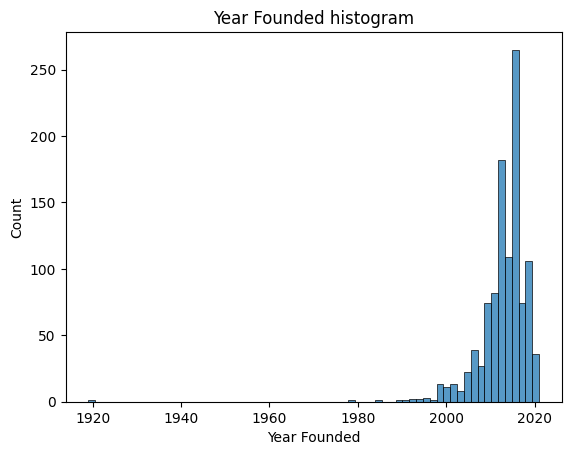

In [29]:
# Plot histogram of the Year Founded feature
sns.histplot(data=companies, x='Year Founded')
plt.title('Year Founded histogram')

On this histogram, company formation increases over time, with a concentration in more recent years

### Weekly Trends (2015)

Weekly groupings are created to examine how unicorn formation varies throughout the year with a focus on 2014-2015

In [44]:
# Filtering dataset by year of interest (2015)
companies_2015 = companies[
    companies['Date Joined'].dt.year == 2015
]

# Verifying
companies_2015.head()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Month Joined,Year Joined,Time to Unicorn
55,Gusto,$10B,2015-12-18,Fintech,San Francisco,United States,North America,2011,$691M,"General Catalyst Partners, Google Ventures, Kl...",December,2015,4
70,Tanium,$9B,2015-03-31,Cybersecurity,Kirkland,United States,North America,2007,$775M,"Andreessen Horowitz, Nor-Cal Invest, TPG Growth",March,2015,8
72,DJI Innovations,$8B,2015-01-23,Hardware,Shenzhen,China,Asia,2006,$105M,"Accel Partners, Sequoia Capital",January,2015,9
104,WeDoctor,$6B,2015-09-22,Health,Hangzhou,China,Asia,2010,$1B,"Tencent, Morningside Group",September,2015,5
133,Royole Corporation,$5B,2015-08-18,Hardware,Shenzhen,China,Asia,2012,$492M,"Warmsun Holding, IDG Capital Partners",August,2015,3


Next, 2015 will be broken into smaller time intervals, such as months or weeks, to analyze how many companies became unicorns within each interval. This allows for a more detailed view of how unicorn formation changed throughout the year rather than treating it as a single aggregate value. The goal is to capture these patterns in a visualization, making it easier to identify trends, spikes, or periods of lower activity within 2015. 



In [45]:
# Insert 'Week Joined' column to 'companies_2015'
companies_2015.insert(
    3,
    'Week Joined',
    companies_2015['Date Joined'].dt.strftime('%Y-W%V'),
    True
)

# Group 'companies_2015' by 'Week Joined'
# Aggregate count of companies that joined per week of 2015
companies_by_week_2015 = (
    companies_2015
    .groupby(by='Week Joined')['Company']
    .count()
    .reset_index()
    .rename(columns={'Company': 'Company Count'})
)

companies_by_week_2015.head()

,Week Joined,Company Count
0,2015-W01,1
1,2015-W02,1
2,2015-W03,1
3,2015-W04,2
4,2015-W10,1


Creating another subset of the data using an additional year (2014), average valuation from 2014 to 2015 can be assessed, concatenating both subsets into a single Dataframe. Adding a new column `Quarter Joined`, representing the time intervals each company belongs to, the data is grouped and the average `valuation`is calculated.

In [50]:
# 2014 subset
companies_2014 = companies[
    companies['Date Joined'].dt.year == 2014
]

# Concatenate
companies_2014_2015 = pd.concat(
    [
        companies_2014,
        companies_2015.drop(columns='Week Joined')
    ]
)

# Adding group variable 'Quarter Joined'
companies_2014_2015["Quarter Joined"] = (
    companies_2014_2015["Date Joined"]
    .dt.to_period('Q')
    .dt.strftime('%Y-Q%q')
)

# Convert 'Valuation' (string -> numeric)
companies_2014_2015["Valuation"] = (
    companies_2014_2015["Valuation"]
    .str.strip("$B")
    .astype(float)
)

# Create time-based summary, revealing trends across quarters
companies_by_quarter_2014_2015 = (
    companies_2014_2015
    .groupby(by="Quarter Joined")["Valuation"]
    .mean()
    .reset_index()
    .rename(columns={"Valuation": "Average Valuation"})
)

companies_by_quarter_2014_2015.head()

,Quarter Joined,Average Valuation
0,2014-Q1,48.000000
1,2014-Q2,2.500000
2,2014-Q3,3.333333
3,2014-Q4,9.166667
4,2015-Q1,3.000000


## Visualization

### Time to Unicorn by month companies joined

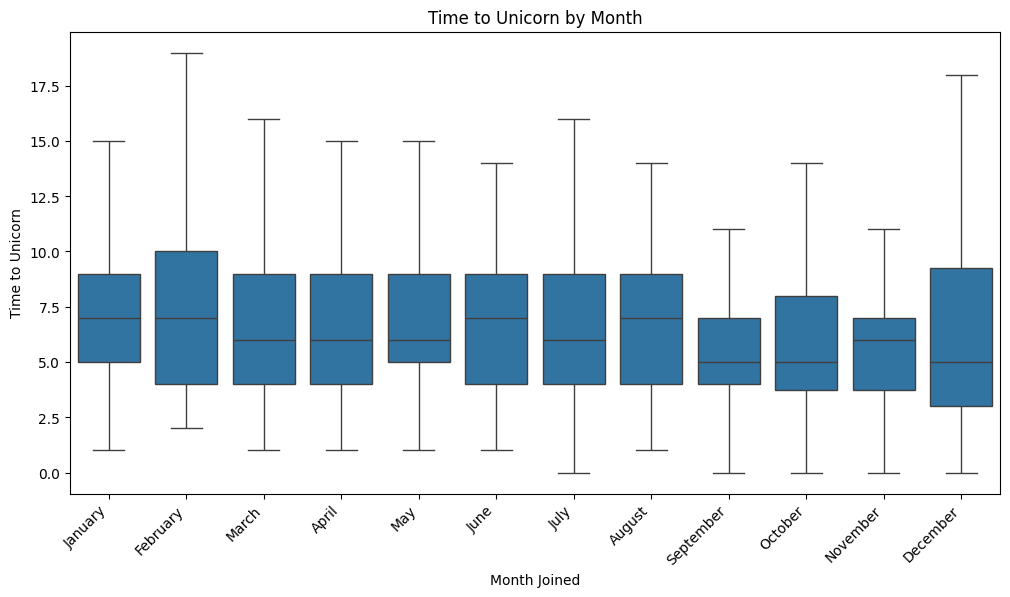

In [36]:
# Set month order
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", 
               "December"]

# Boxplot
plt.figure(figsize=(12,6))

sns.boxplot(x=companies['Month Joined'],
           y=companies['Time to Unicorn'],
           order=month_order,
           showfliers=False)

plt.title('Time to Unicorn by Month')
plt.xticks(rotation=45, horizontalalignment='right')
plt.show()

### Insights

- Time to unicorn varies across months but does not show a strong seasonal pattern

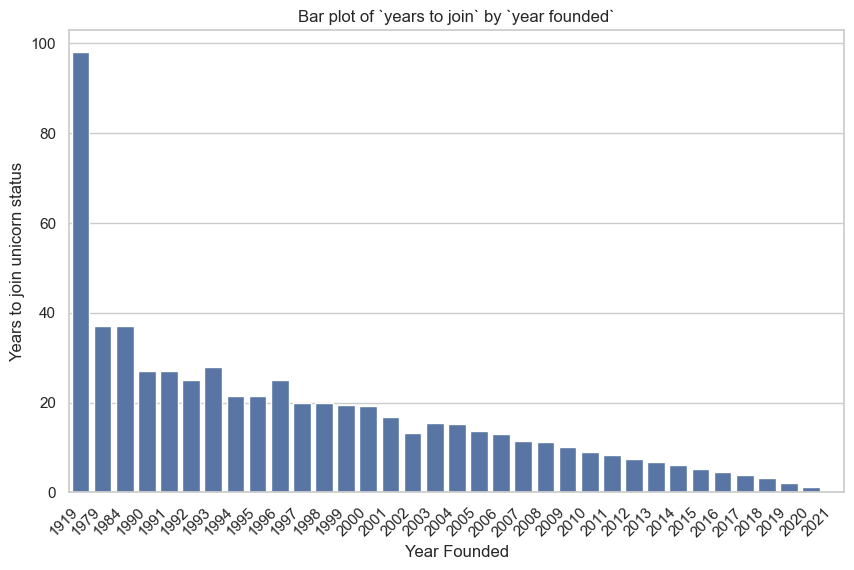

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=companies["Year Founded"],
    y=companies["Time to Unicorn"],
    errorbar=('ci',False)
)

plt.title('Bar plot of `years to join` by `year founded`')
plt.xlabel('Year Founded')
plt.ylabel('Years to join unicorn status')
plt.xticks(rotation=45, horizontalalignment='right')
plt.show()

### Insights

Companies founded in more recent years appear to reach unicorn status more quickly on average. However, this trend is likely affected by time-based bias, as newer companies have had less time to be observed. Companies that take longer to reach unicorn status are not yet observed in the data for more recent founding years, which leads to an overrepresentation of faster-growing companies and could create a misleading trend. 

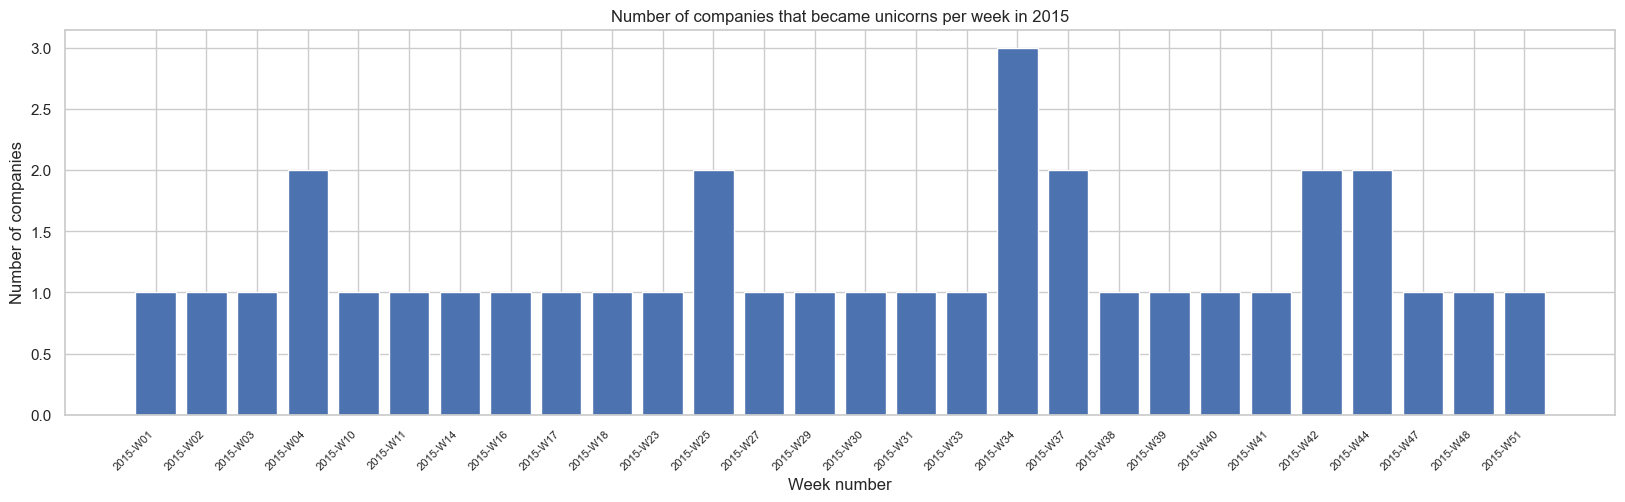

In [56]:
# Companies that joined in 2015
plt.figure(figsize=(20,5))

# Bar plot of companies reaching unicorn status per week in 2015
plt.bar(
    x=companies_by_week_2015['Week Joined'],
    height=companies_by_week_2015['Company Count']
)

plt.xlabel('Week number')
plt.ylabel('Number of companies')
plt.title('Number of companies that became unicorns per week in 2015')
plt.xticks(rotation=45, horizontalalignment='right', fontsize=8)
plt.show()
    

### Insights

The weekly counts are fairly consistent, with only small increases in a few weeks. There is no clear pattern or concentration of activity, suggesting companies reached unicorn status consistently throughout the year with variations likely representing noise rather than a meaningful trend.

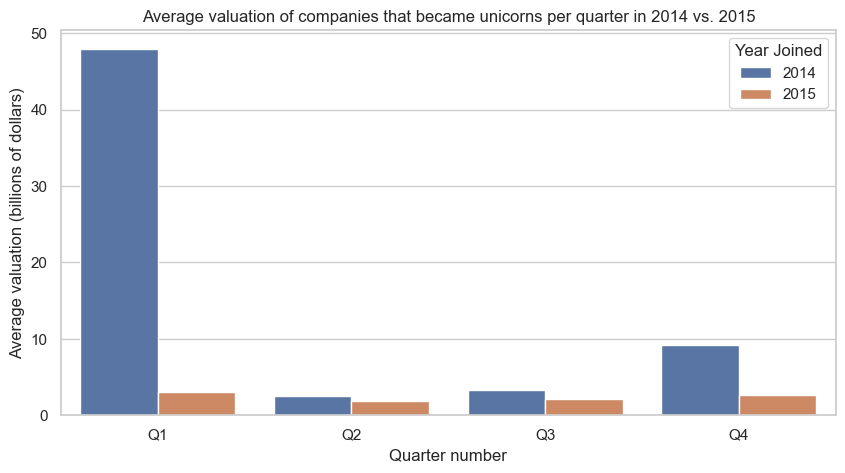

In [58]:
# Extract quarter and year
companies_by_quarter_2014_2015['Quarter Number'] = (
    companies_by_quarter_2014_2015['Quarter Joined'].str[-2:]
)

companies_by_quarter_2014_2015['Year Joined'] = (
    companies_by_quarter_2014_2015['Quarter Joined'].str[:4]
)

# Plot
plt.figure(figsize=(10,5))

sns.barplot(
    x=companies_by_quarter_2014_2015['Quarter Number'],
    y=companies_by_quarter_2014_2015['Average Valuation'],
    hue=companies_by_quarter_2014_2015['Year Joined']
)

plt.xlabel('Quarter number')
plt.ylabel('Average valuation (billions of dollars)')
plt.title('Average valuation of companies that became unicorns per quarter in 2014 vs. 2015')

plt.show()

### Insight

Average valuations are consistently higher in 2014 than in 2015, with a significant spike in Q1 2014. 2015 remains relatively flat across all quarters. The sharp increas in early 2014 suggests the presence of outliers, rather than a sustained difference across the entire year. 

# Key Insights

- There is a clear time-based bias in the data. Companies founded in more recent years have had less time to reach unicorn status, so the dataset is more likely to include only those that scaled quickly, while slower-growing companies are not yet observed. This can make it appear as though newer companies consistently reach unicorn status faster, even though that may not fully reflect reality.

- The analysis also highlights the importance of outliers and how they can influence averages, suggesting comparing mean and median values cn provide a clearer picture.

- **Recommendations**: I would recommend not relying on the assumptiono that newer companies grow faster, as this may be driven by time-based bias. Stakeholders should also be cautious when using average valuations and consider more robust measures like the median. Since no clear seasonal patterns were observed, timing-based decisions may not be meaningful, and focus should instead by placed on factors like industry and funding. 